In [ ]:
!pip install yfinance
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218910 sha256=d4b94c2f4ac77f58ff5ff22dc62a7e9b388fddf5891373a6484932013587c779
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set(style = "whitegrid")
from statsmodels.tsa.stattools import adfuller, coint
from datetime import datetime, timedelta

In [ ]:

import yfinance as yf

# Dictionary: sector name → list of tickers
stock_sectors = {
    "Technology": ["AAPL", "MSFT", "NVDA"],
    "Finance": ["JPM", "BAC", "GS"],
    "Energy": ["XOM", "CVX", "COP"],
    "Consumer Staples": ["PG", "KO", "WMT"],
    "Healthcare": ["JNJ", "UNH", "PFE"],
    "Industrial": ["CAT", "BA", "MMM"]
}

# Flatten the list of all stocks
stocks = [stock for sector in stock_sectors.values() for stock in sector]

# Set the start and end dates
start_date = "2019-04-01"
end_date = "2025-03-31"

# Download the stock data for all stocks
data = yf.download(stocks, start=start_date, end=end_date)

# Extract only the 'Adj Close' prices
close_data = data['Close']

# Display the first few rows of adjusted close prices
print(close_data.head())


/tmp/ipython-input-2006748917.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start=start_date, end=end_date)
[*********************100%***********************]  18 of 18 completed

Ticker           AAPL          BA        BAC         CAT        COP  \
Date                                                                  
2019-04-01  45.698475  382.369537  24.468727  121.510857  54.347858   
2019-04-02  46.362762  381.597992  24.751654  121.458900  53.271992   
2019-04-03  46.680592  375.728760  24.725927  120.653099  52.597572   
2019-04-04  46.761841  386.588318  24.991703  121.406906  52.316536   
2019-04-05  47.074871  382.750366  24.931686  121.606155  53.087322   

Ticker            CVX          GS         JNJ        JPM         KO  \
Date                                                                  
2019-04-01  94.875496  169.560303  116.503746  87.116974  38.561028   
2019-04-02  94.867912  170.215302  115.439133  87.533241  38.437229   
2019-04-03  94.078163  173.111145  114.986435  87.708076  38.115330   
2019-04-04  94.769188  174.291885  113.645233  88.555374  38.362942   
2019-04-05  95.999367  174.421158  114.156555  88.345642  38.354702   

Tick

In [ ]:
close_data

Ticker,AAPL,BA,BAC,CAT,COP,CVX,GS,JNJ,JPM,KO,MMM,MSFT,NVDA,PFE,PG,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,
2019-04-01,45.698475,382.369537,24.468727,121.510857,54.347858,94.875496,169.560303,116.503746,87.116974,38.561028,139.652634,112.229797,4.524251,30.284420,88.105583,222.665649,29.656841,60.768967
2019-04-02,46.362762,381.597992,24.751654,121.458900,53.271992,94.867912,170.215302,115.439133,87.533241,38.437229,139.777878,112.390091,4.542120,30.333910,88.199104,221.640930,29.390049,60.508739
2019-04-03,46.680592,375.728760,24.725927,120.653099,52.597572,94.078163,173.111145,114.986435,87.708076,38.115330,140.436783,113.125603,4.681612,30.284420,88.148102,222.937698,29.465847,60.151833
2019-04-04,46.761841,386.588318,24.991703,121.406906,52.316536,94.769188,174.291885,113.645233,88.555374,38.362942,141.688736,112.550385,4.672675,30.213726,87.927078,224.343323,29.744770,61.006882
2019-04-05,47.074871,382.750366,24.931686,121.606155,53.087322,95.999367,174.421158,114.156555,88.345642,38.354702,141.939148,113.050148,4.739443,30.390451,88.114090,225.603790,29.963060,61.334045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24,220.191025,180.899994,42.817677,338.791687,101.327637,163.034195,577.222778,161.902023,245.359375,68.463226,152.403564,392.359680,121.401573,25.215555,163.505692,512.859314,87.278976,114.743195
2025-03-25,223.203659,182.589996,43.026443,339.733673,101.684601,163.943115,583.033875,159.651321,248.395950,68.324211,152.751877,394.435883,120.681625,24.646421,160.741943,509.810944,84.555565,115.525978
2025-03-26,220.989075,178.550003,42.569141,338.236389,102.329109,165.948685,571.073425,160.345367,248.297043,69.525665,151.935852,389.255402,113.752106,24.318445,164.423660,514.547302,85.004478,117.190651


In [ ]:
close_data.columns

Index(['AAPL', 'BA', 'BAC', 'CAT', 'COP', 'CVX', 'GS', 'JNJ', 'JPM', 'KO',
       'MMM', 'MSFT', 'NVDA', 'PFE', 'PG', 'UNH', 'WMT', 'XOM'],
      dtype='object', name='Ticker')

/tmp/ipython-input-1621963293.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = close_data.resample('M').last()


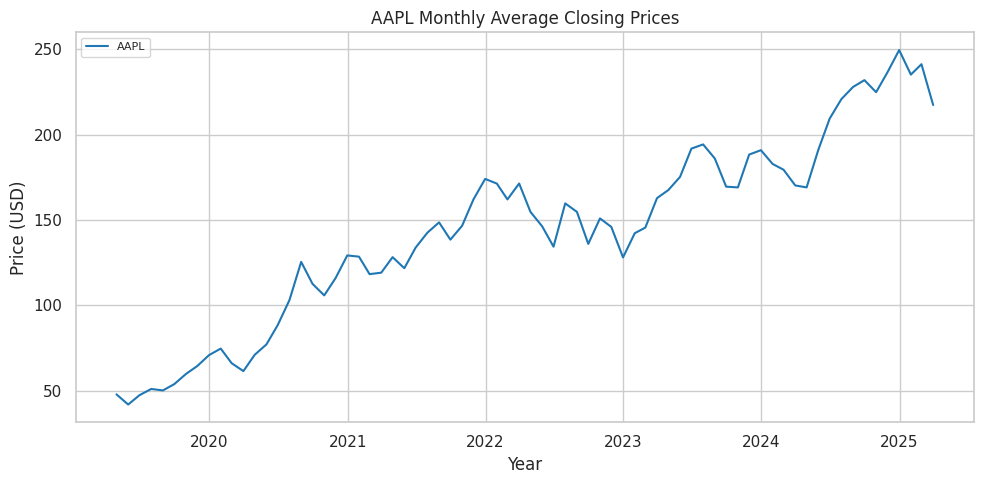

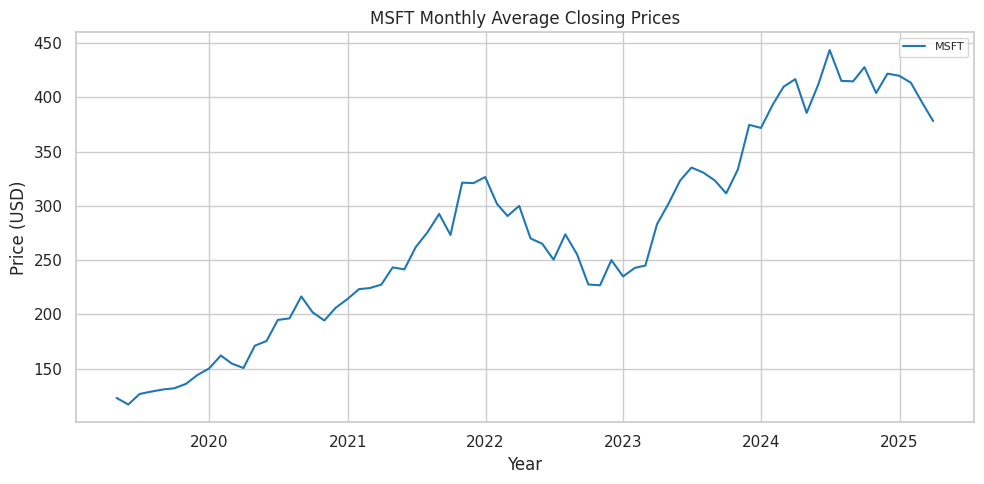

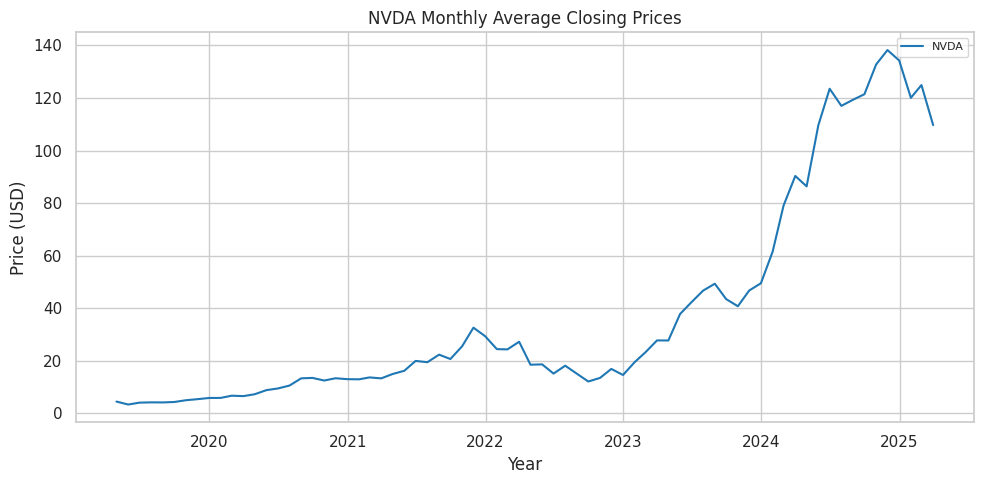

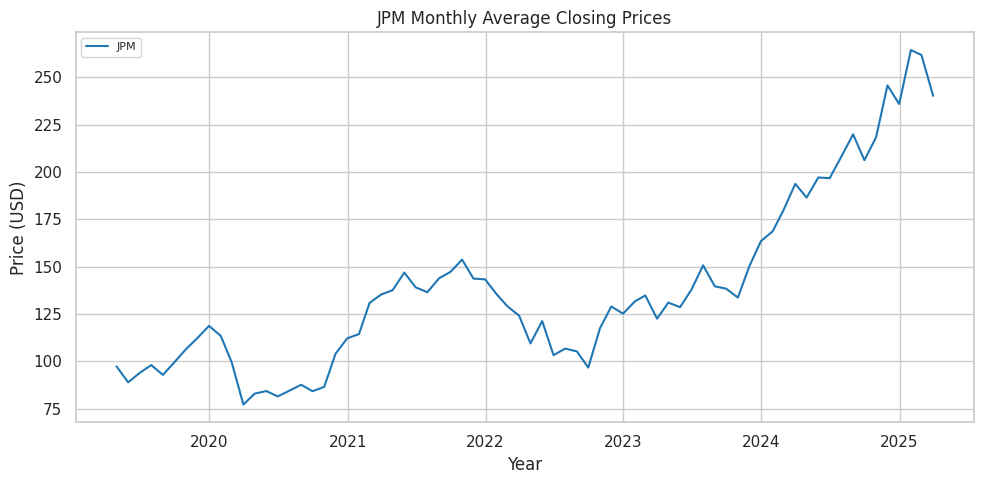

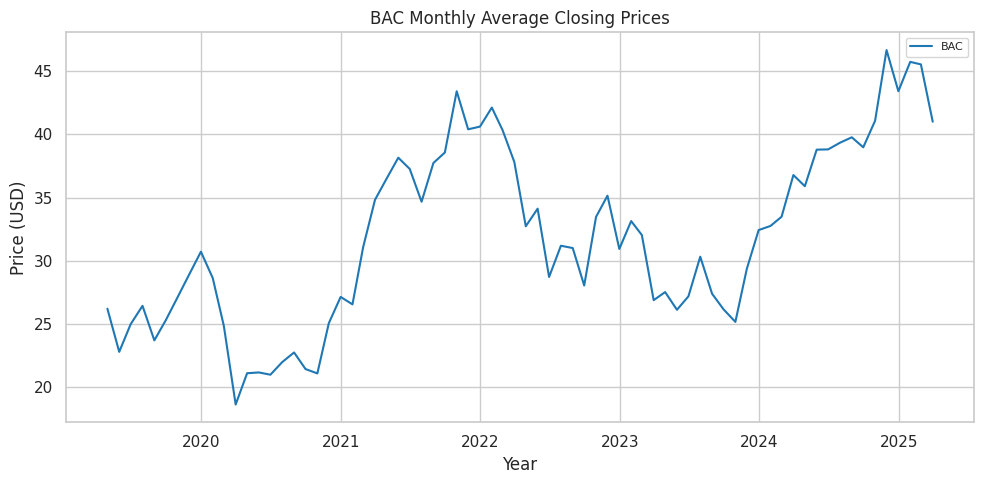

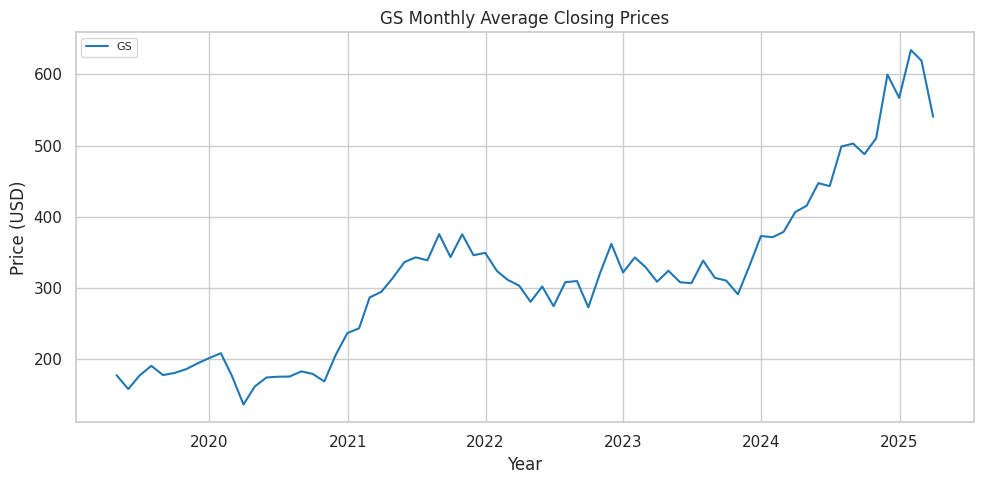

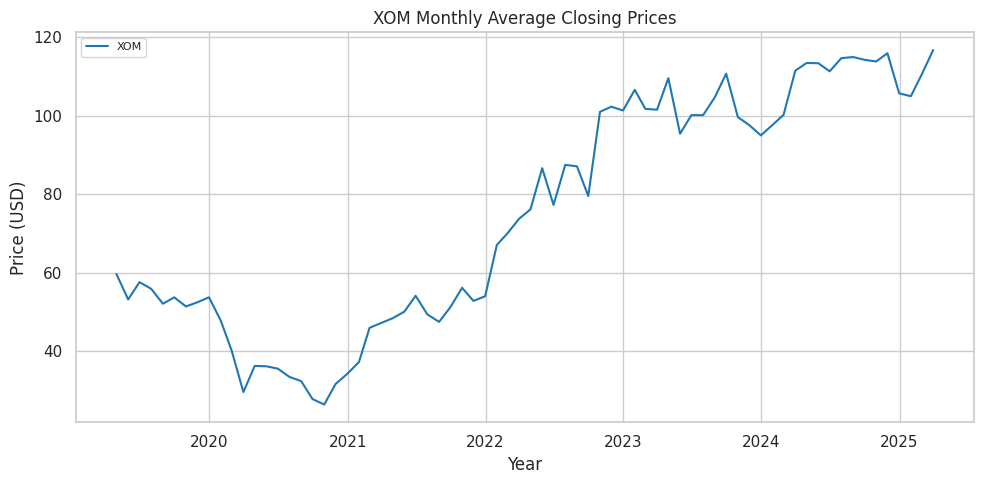

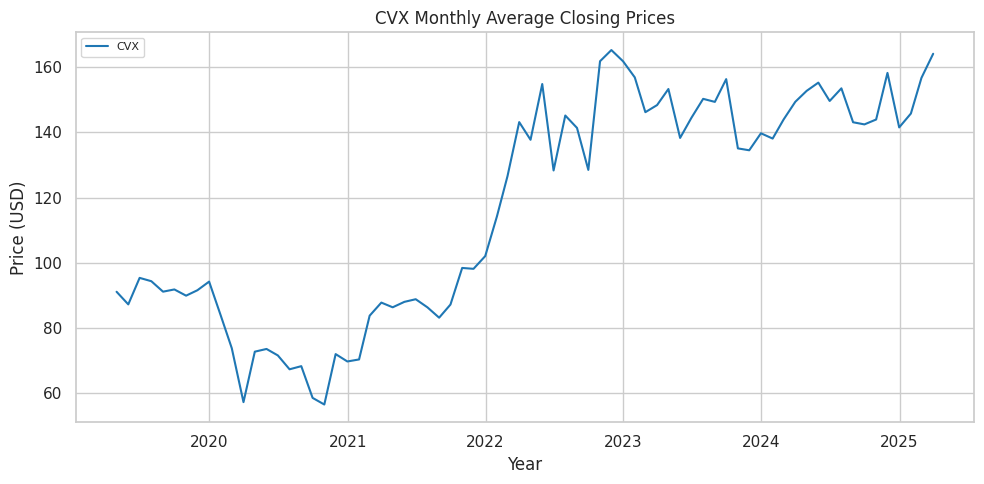

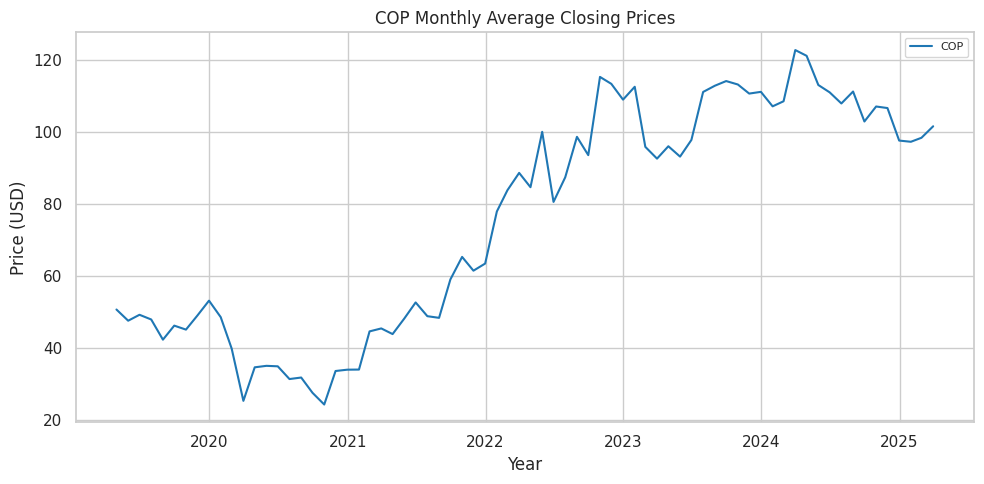

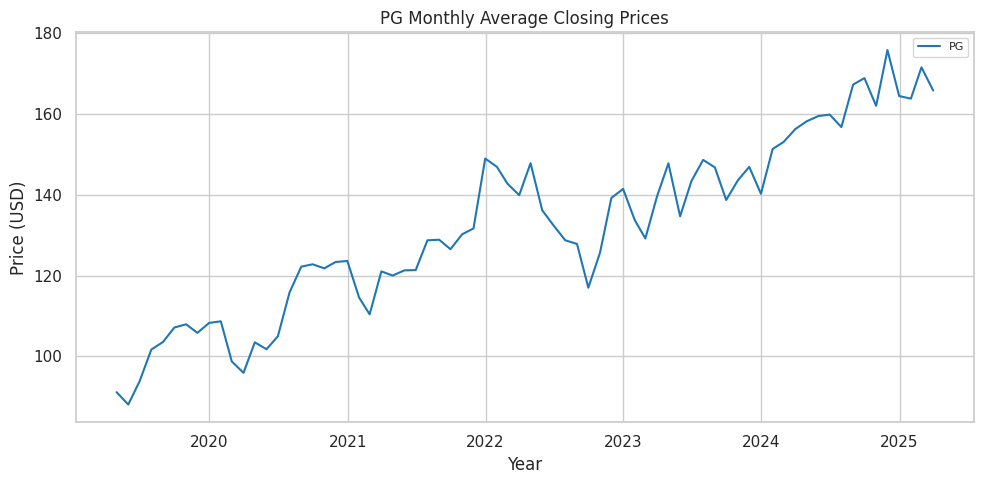

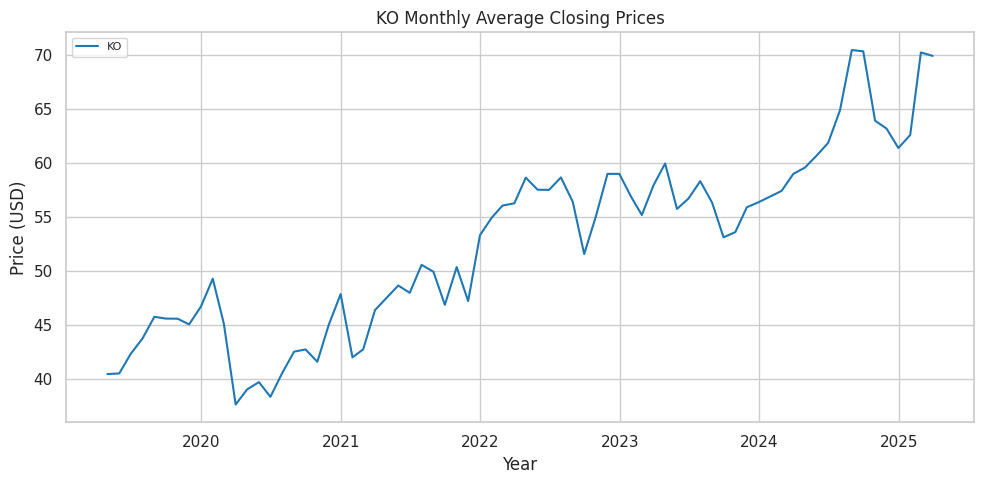

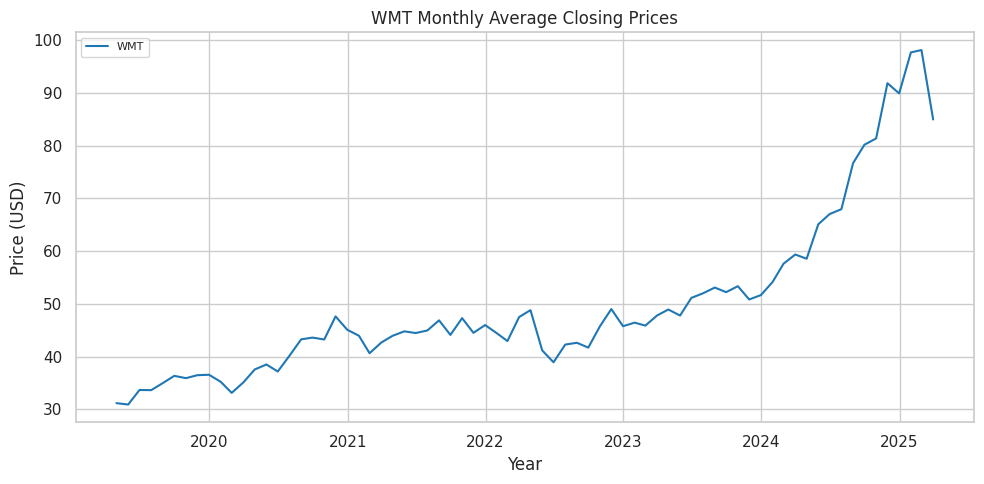

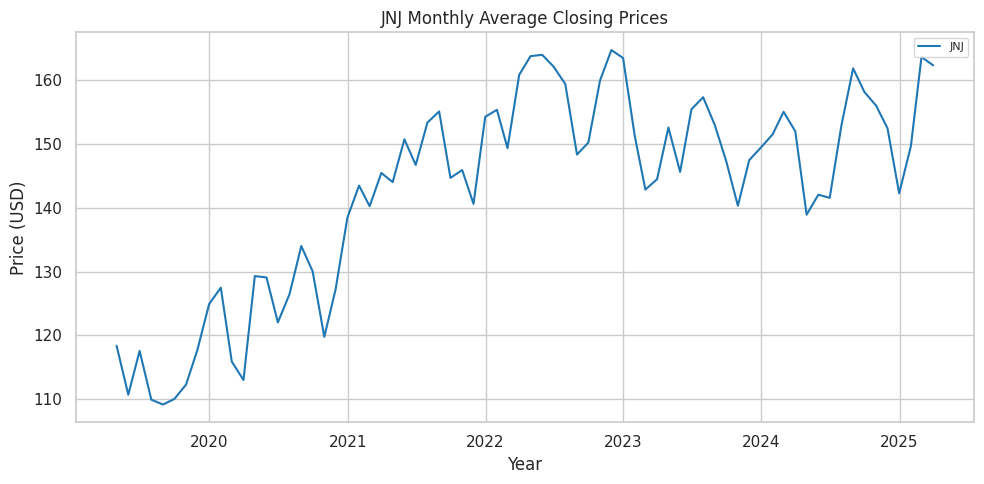

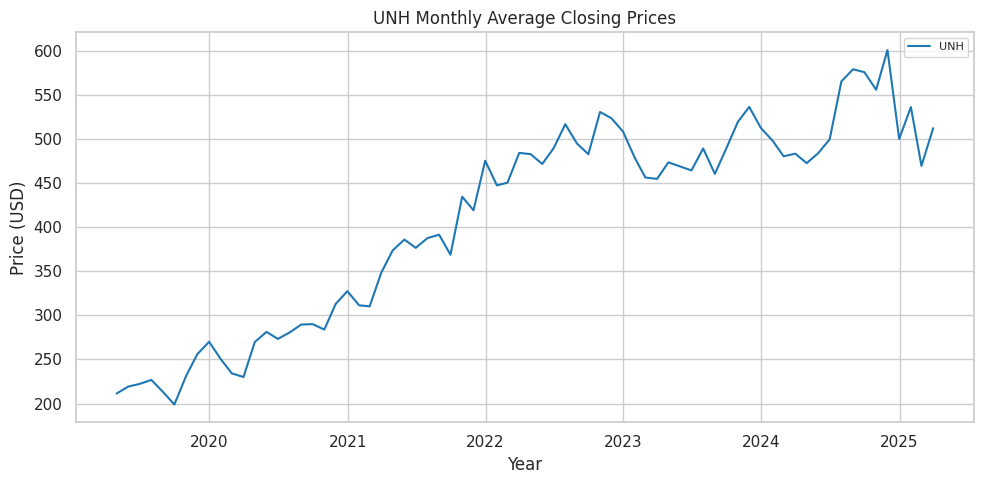

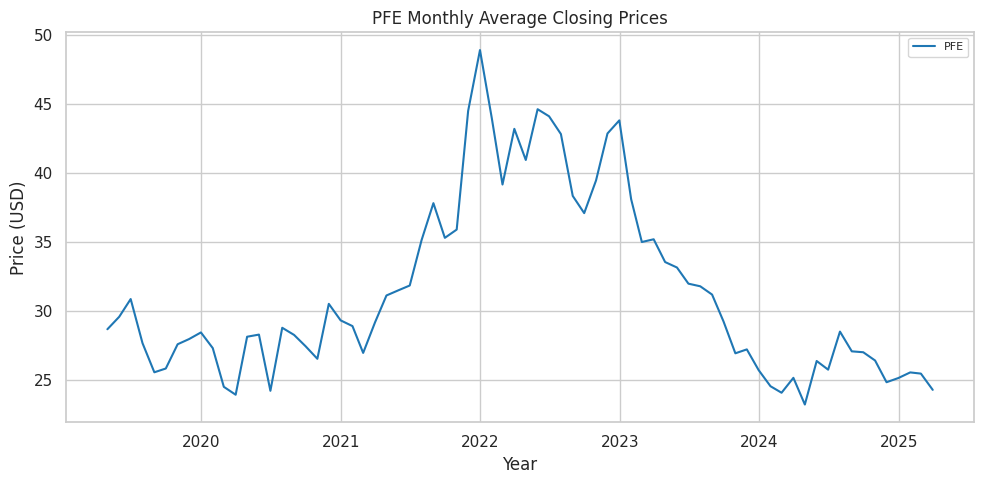

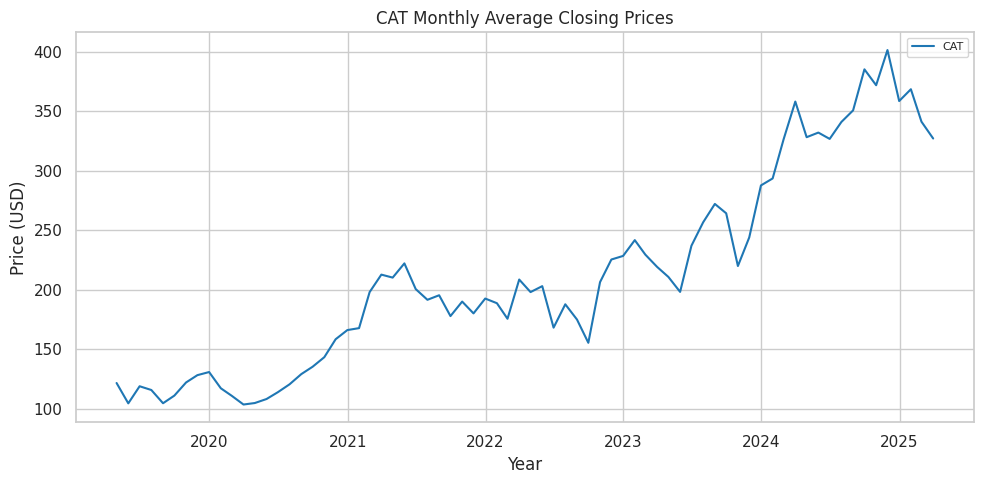

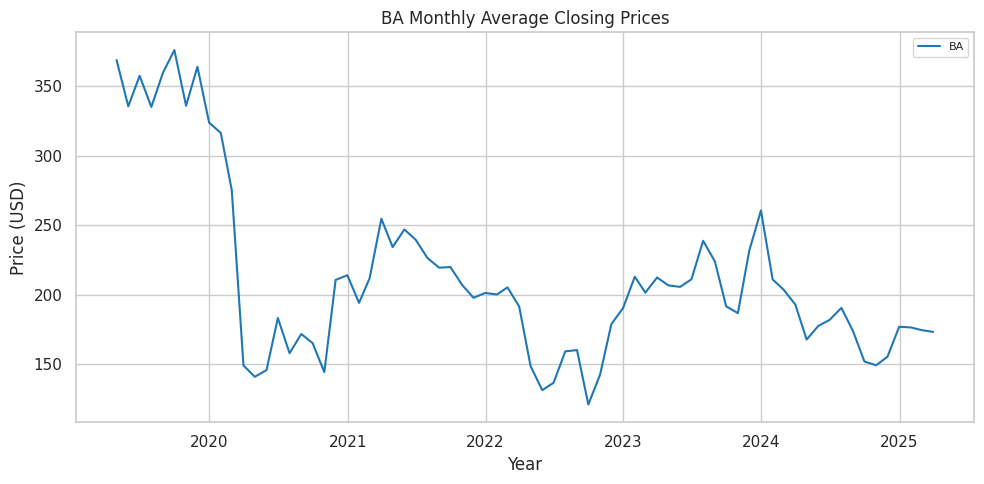

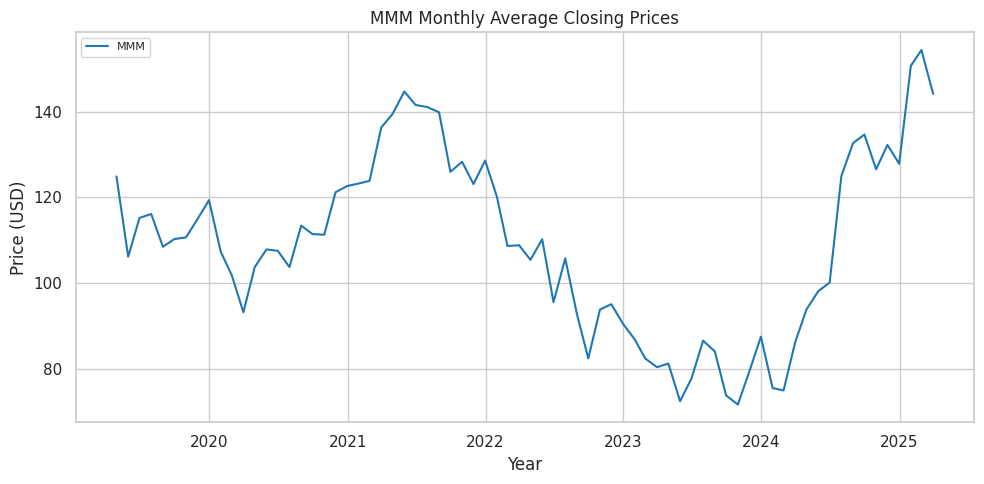

In [ ]:
import matplotlib.dates as mdates

if isinstance(data.columns, pd.MultiIndex):
    close_data = data['Close']
    close_data.columns = close_data.columns.get_level_values(0)
else:
    close_data = data['Close']

monthly_data = close_data.resample('M').last()

for stock in stocks:
    plt.figure(figsize=(10, 5))
    plt.plot(monthly_data.index, monthly_data[stock], label=stock, color='tab:blue')
    plt.title(f"{stock} Monthly Average Closing Prices")
    plt.xlabel("Year")
    plt.ylabel("Price (USD)")
    plt.grid(True)

    # Format x-axis to show years only
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=0)

    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
monthly_returns = monthly_data.pct_change()

In [ ]:
price_apr_30 =close_data.loc['2019-04-30', 'AAPL']

# Get price on 31 May 2019
price_may_31 = close_data.loc['2019-05-31', 'AAPL']

In [ ]:
mean_monthly_return = monthly_returns.mean()
print(mean_monthly_return)

Ticker
AAPL    0.024898
BA     -0.001929
BAC     0.010378
CAT     0.018060
COP     0.016759
CVX     0.012284
GS      0.019764
JNJ     0.005696
JPM     0.015831
KO      0.009084
MMM     0.005105
MSFT    0.017766
NVDA    0.055853
PFE     0.000487
PG      0.009698
UNH     0.014702
WMT     0.015790
XOM     0.013721
dtype: float64


In [ ]:
std_monthly_return = monthly_returns.std()
std_monthly_return

,0
Ticker,
AAPL,0.083646
BA,0.130248
BAC,0.089970
CAT,0.091810
COP,0.120079
CVX,0.091112
GS,0.089900
JNJ,0.050326
JPM,0.078211


In [ ]:
returnRisk = pd.DataFrame({
    'Mean Monthly Return': mean_monthly_return,
    'Monthly Std Dev (Risk)': std_monthly_return
})

# Sort by highest return
print(returnRisk.sort_values('Mean Monthly Return', ascending=False))

# Sort by lowest risk
print(returnRisk.sort_values('Monthly Std Dev (Risk)'))


        Mean Monthly Return  Monthly Std Dev (Risk)
Ticker                                             
NVDA               0.055853                0.142376
AAPL               0.024898                0.083646
GS                 0.019764                0.089900
CAT                0.018060                0.091810
MSFT               0.017766                0.061776
COP                0.016759                0.120079
JPM                0.015831                0.078211
WMT                0.015790                0.056422
UNH                0.014702                0.066755
XOM                0.013721                0.093471
CVX                0.012284                0.091112
BAC                0.010378                0.089970
PG                 0.009698                0.050314
KO                 0.009084                0.052273
JNJ                0.005696                0.050326
MMM                0.005105                0.079687
PFE                0.000487                0.076859
BA          

In [ ]:
sector_codes = {
    "Technology": 1,
    "Finance": 2,
    "Energy": 3,
    "Consumer Staples": 4,
    "Healthcare": 5,
    "Industrial": 6
}

# Create a ticker to sector code dictionary
ticker_to_sector_code = {}
for sector, tickers in stock_sectors.items():
    code = sector_codes[sector]
    for ticker in tickers:
        ticker_to_sector_code[ticker] = code


In [ ]:
returnRisk.columns

Index(['Mean Monthly Return', 'Monthly Std Dev (Risk)'], dtype='object')

In [ ]:
# Step 1: Get average risk-free rate (already provided in earlier code)
tnx = yf.download("^TNX", start="2019-04-01", end="2022-03-31", interval='1mo')
tnx_yield = tnx['Close'] / 10
tnx_yield.index = pd.to_datetime(tnx_yield.index)
avg_rf_per_year = tnx_yield.groupby(tnx_yield.index.year).mean()
avg_rf_per_year = avg_rf_per_year.loc[[2019, 2020, 2021, 2022]]
avg_rf = avg_rf_per_year.mean().item() / 100

print(f"\nAverage Risk-Free Rate (2019–2022): {avg_rf:.4f}")

# Step 2: Compute excess return and sparse ratio
returnRisk['excess_return'] = returnRisk['Mean Monthly Return'] - avg_rf
returnRisk['sharpe_ratio'] = returnRisk['excess_return'] / returnRisk['Monthly Std Dev (Risk)']

# Step 3: Create summary DataFrame
summary = returnRisk[['Mean Monthly Return', 'Monthly Std Dev (Risk)', 'sharpe_ratio']].copy()
summary.columns = ['Mean Monthly Return', 'Monthly Std Dev (Risk)', 'Sharpe Ratio']

# Step 4: Print sorted summaries
print("\nSorted by Highest Mean Monthly Return:")
print(summary.sort_values('Mean Monthly Return', ascending=False))

print("\nSorted by Lowest Monthly Risk:")
print(summary.sort_values('Monthly Std Dev (Risk)'))

print("\nSorted by Highest Sharpe Ratio:")
print(summary.sort_values('Sharpe Ratio', ascending=False))


/tmp/ipython-input-1956003394.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tnx = yf.download("^TNX", start="2019-04-01", end="2022-03-31", interval='1mo')
[*********************100%***********************]  1 of 1 completed


Average Risk-Free Rate (2019–2022): 0.0015

Sorted by Highest Mean Monthly Return:
        Mean Monthly Return  Monthly Std Dev (Risk)  Sharpe Ratio
Ticker                                                           
NVDA               0.055853                0.142376      0.381450
AAPL               0.024898                0.083646      0.279201
GS                 0.019764                0.089900      0.202666
CAT                0.018060                0.091810      0.179897
MSFT               0.017766                0.061776      0.262590
COP                0.016759                0.120079      0.126711
JPM                0.015831                0.078211      0.182673
WMT                0.015790                0.056422      0.252484
UNH                0.014702                0.066755      0.197116
XOM                0.013721                0.093471      0.130272
CVX                0.012284                0.091112      0.117874
BAC                0.010378                0.089970      0

In [ ]:
returnRisk.head()

,Mean Monthly Return,Monthly Std Dev (Risk),excess_return,sparse_ratio,sharpe_ratio
Ticker,,,,,
AAPL,0.024898,0.083646,0.023354,0.279201,0.279201
BA,-0.001929,0.130248,-0.003473,-0.026667,-0.026667
BAC,0.010378,0.089970,0.008834,0.098185,0.098185
CAT,0.018060,0.091810,0.016516,0.179897,0.179897
COP,0.016759,0.120079,0.015215,0.126711,0.126711


In [ ]:
returnRisk = returnRisk.reset_index()  # moves index 'Ticker' into a column


In [ ]:
returnRisk.head()

,index,Ticker,Mean Monthly Return,Monthly Std Dev (Risk),excess_return,sparse_ratio,sharpe_ratio
0,0,AAPL,0.024898,0.083646,0.023354,0.279201,0.279201
1,1,BA,-0.001929,0.130248,-0.003473,-0.026667,-0.026667
2,2,BAC,0.010378,0.089970,0.008834,0.098185,0.098185
3,3,CAT,0.018060,0.091810,0.016516,0.179897,0.179897
4,4,COP,0.016759,0.120079,0.015215,0.126711,0.126711


In [ ]:
returnRisk.columns

Index(['Mean Monthly Return', 'Monthly Std Dev (Risk)', 'excess_return',
       'sparse_ratio', 'sharpe_ratio'],
      dtype='object')

In [ ]:
sector_codes = {
    "Technology": 1,
    "Finance": 2,
    "Energy": 3,
    "Consumer Staples": 4,
    "Healthcare": 5,
    "Industrial": 6
}

# Create a ticker to sector name dictionary
ticker_to_sector = {}
for sector, tickers in stock_sectors.items():
    for ticker in tickers:
        ticker_to_sector[ticker] = sector  # store sector name, not code for grouping

# Add sector column to returnRisk using mapping
returnRisk["sector"] = returnRisk["Ticker"].map(ticker_to_sector)

# Take top 2 stocks per sector based on sparse_ratio
final_stocks = (
    returnRisk
    .sort_values("sparse_ratio", ascending=False)
    .groupby("sector")
    .head(2)  # top 2 from each sector
)

# Display result
print("Top 2 Stocks per Sector by Sparse Ratio:")
print(final_stocks [["Ticker", "sector", "sparse_ratio"]])


Top 2 Stocks per Sector by Sparse Ratio:
   Ticker            sector  sparse_ratio
12   NVDA        Technology      0.381450
0    AAPL        Technology      0.279201
16    WMT  Consumer Staples      0.252484
6      GS           Finance      0.202666
15    UNH        Healthcare      0.197116
8     JPM           Finance      0.182673
3     CAT        Industrial      0.179897
14     PG  Consumer Staples      0.162063
17    XOM            Energy      0.130272
4     COP            Energy      0.126711
7     JNJ        Healthcare      0.082496
10    MMM        Industrial      0.044693


In [ ]:
final_stocks.head()

,index,Ticker,Mean Monthly Return,Monthly Std Dev (Risk),excess_return,sparse_ratio,sharpe_ratio,sector
12,12,NVDA,0.055853,0.142376,0.054309,0.381450,0.381450,Technology
0,0,AAPL,0.024898,0.083646,0.023354,0.279201,0.279201,Technology
16,16,WMT,0.015790,0.056422,0.014246,0.252484,0.252484,Consumer Staples
6,6,GS,0.019764,0.089900,0.018220,0.202666,0.202666,Finance
15,15,UNH,0.014702,0.066755,0.013158,0.197116,0.197116,Healthcare


In [ ]:
final_stocks.columns

Index(['index', 'Ticker', 'Mean Monthly Return', 'Monthly Std Dev (Risk)',
       'excess_return', 'sparse_ratio', 'sharpe_ratio', 'sector'],
      dtype='object')

In [ ]:
import cvxpy as cp
import numpy as np

# Step 1: Select tickers from your final_stocks
selected_tickers = final_stocks["Ticker"].tolist()

# Step 2: Mean returns vector (from your dataset)
mean_returns = final_stocks.set_index("Ticker").loc[selected_tickers, "Mean Monthly Return"].values

# Step 3: Covariance matrix (from monthly_returns dataframe)
selected_monthly_returns = monthly_returns[selected_tickers]  # must have historical monthly returns
cov_matrix = selected_monthly_returns.cov().values  # .values to get numpy matrix

# Step 4: Set risk aversion parameter
lambda_val = 3 # Try 0, 1, 5, 10

# Step 5: Define optimization variable
w = cp.Variable(len(selected_tickers))

# Step 6: Define objective (mean-variance utility)
objective = cp.Maximize(w @ mean_returns - 0.5 * lambda_val * cp.quad_form(w, cov_matrix))

# Step 7: Constraints (weights sum to 1, no other constraints yet)
constraints = [cp.sum(w) == 1]

# Step 8: Solve the problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Step 9: Output results
optimal_weights = w.value
print("Optimal Portfolio Weights:")
for ticker, weight in zip(selected_tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")


Optimal Portfolio Weights:
NVDA: 0.7292
AAPL: 0.1884
WMT: 0.5398
GS: 0.4106
UNH: 0.8684
JPM: -0.2283
CAT: 0.0984
PG: -0.0005
XOM: 0.2384
COP: 0.0631
JNJ: -0.8452
MMM: -1.0624


λ=0.0: No optimal solution found


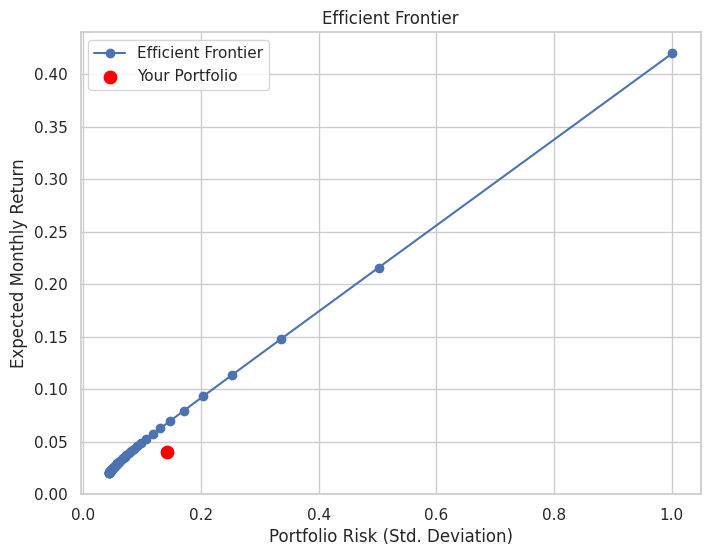

In [ ]:
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np

# Range of lambda values (risk aversion levels)
lambda_values = np.linspace(0, 20, 50)

returns_list = []
risks_list = []
weights_list = []

for lam in lambda_values:
    w_var = cp.Variable(len(selected_tickers))
    objective = cp.Maximize(w_var @ mean_returns_array - 0.5 * lam * cp.quad_form(w_var, cov_matrix))
    constraints = [cp.sum(w_var) == 1]  # add w_var >= 0 if no short selling
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS)  # or cp.ECOS

    if problem.status in ["optimal", "optimal_inaccurate"]:
        w_opt = w_var.value
        weights_list.append(w_opt)
        port_return = np.dot(w_opt, mean_returns_array)
        returns_list.append(port_return)
        port_risk = np.sqrt(np.dot(w_opt.T, np.dot(cov_matrix, w_opt)))
        risks_list.append(port_risk)
    else:
        print(f"λ={lam}: No optimal solution found")

# Plot Efficient Frontier
plt.figure(figsize=(8, 6))
plt.plot(risks_list, returns_list, marker='o', label="Efficient Frontier")

plt.scatter(np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights))),
            expected_return_pct, color='red', label="Your Portfolio", s=80)

# Set x-axis ticks with step 0.2
plt.xticks(np.arange(round(min(risks_list), 1), round(max(risks_list) + 0.2, 1), 0.2))

plt.xlabel("Portfolio Risk (Std. Deviation)")
plt.ylabel("Expected Monthly Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()
